# DTAT311. deeptrack.properties

<a href="https://colab.research.google.com/github/DeepTrackAI/DeepTrack2/blob/develop/tutorials/3-advanced-topics/DTAT311_properties.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# !pip install deeptrack  # Uncomment if running on Colab/Kaggle.

This advanced tutorial introduces the module `properties.py`.

## 1. What is `properties.py`?

The `properties.py` module in DeepTrack2 defines the mechanisms for managing the dynamic and hierarchical properties of features. Unlike standard Python attributes, these properties support lazy evaluation, inheritance, dependency tracking, and value caching. This makes them ideal for defining complex, data-driven feature graphs where values may depend on other values—either statically or dynamically. The properties' system is tightly integrated with the `Feature` class, serving as the foundation for the flexible and declarative interface used to build DeepTrack2 pipelines.

The key roles of `properties.py` are:

- **Lazy-Evaluated Properties:**
  Properties can be set as static values or as callables, allowing for on-demand evaluation. This is critical for dynamic data pipelines where some values depend on runtime conditions.

- **Tracking of Dependencies Between Properties:**
  Properties can depend on other properties. When a dependency is updated, dependent properties are automatically re-evaluated. This enables consistent and efficient parameter propagation.

- **Hierarchical Property Inheritance:**
  Sub-features can inherit and override properties from their parent features, enabling modular and composable configurations.

- **Introspection and Documentation:**
  Properties can be introspected to extract their default values, types, and documentation, which supports automated documentation generation and better developer experience.

- **Evaluated Values Caching:**
  Once evaluated, a property's value is cached until its dependencies change. This prevents unnecessary recomputation while ensuring correctness.

- **Declarative Syntax for Pipeline Specification:**
  The use of properties allows DeepTrack users to define image generation pipelines in a high-level, declarative manner while retaining low-level control when needed.

## 2. What is a Property?

Each feature (instance of the class `Feature`, see [DTAT301_features.ipynb](DTAT301_features.ipynb)) can have several properties (instances of the class `Property`). These properties can be constants, functions, lists, dictionaries, iterators, or slices, providing flexibility in defining and controlling different aspects of the system being modelled.

A propety has a value accessible through the field `current_value`, whose data type is not restricted. 
This value is updated through a sampling rule (used by the `.update()` method), which is passed to the class constructor on initialization. 

### 2.1. What is a sampling rule?

The sampling rule determines how the value of a property is updated upon calling `.update()`.
A sampling rule is defined when an instance of the class `Property` is created and can be of any type. 
When calling `.update()`, the value of the property is updated according to the first of the following that applies:
    
1.  If the sampling rule is a `DeepTrackNode` (e.g., another property or feature), it returns the value sampled.

2.  If the sampling rule is a ``dict``, sample each value and combine the result into a new ``dict`` using the original keys. 

3.  If the sampling rule is a ``list``, sample each element of the list and combine the result into a new ``list``.

4.  If the sampling rule is an iterable, return the next value. If the iterable is exhausted, the value of the property is not changed.

5.  If the sampling rule is callable, call it and return the result.

6.  If none of the above apply, return the sampling rule itself.

### 2.2. Property with a Constant Value

The simplest example of a property is one that does not change during an update call.
This is commonly either a number or a tuple, but can be any data type that will be evaluated by case 6 above.
If you want to have a constant property with a value that would be evaluated by cases 1-5 (e.g., a list or a function), you can  wrap it as the output of a lambda function.

In [2]:
from deeptrack.properties import Property

In [3]:
# Number

P = Property(1)
print(f"The current value of the property is {P()}")

P.update()  # Numbers are not changed after an update() call
print(f"The current value of the property is {P()}")

The current value of the property is 1
The current value of the property is 1


In [4]:
# Tuple

P = Property((1, [2, 3], None))
print(f"The current value of the property is {P()}")

P.update()  # Tuples are not changed after an update() call
print(f"The current value of the property is {P()}")

The current value of the property is (1, [2, 3], None)
The current value of the property is (1, [2, 3], None)


In [5]:
# Wrapped list

import numpy as np

P = Property(lambda: [np.random.rand, 1, {}])
print(f"The current value of the property is {P()}")

P.update()  # Objects wrapped in functions are not changed by an update() call
print(f"The current value of the property is {P()}")

The current value of the property is [<built-in method rand of numpy.random.mtrand.RandomState object at 0x10fad2e40>, 1, {}]
The current value of the property is [<built-in method rand of numpy.random.mtrand.RandomState object at 0x10fad2e40>, 1, {}]


### 2.3. Property with a Discrete Random Value 

Discrete randomness can be achieved by a function (case 5).

In [6]:
# Function

P = Property(lambda: np.random.randint(0, 10))

for _ in range(5):
    P.update()
    print(f"The current value of the property is {P()}")


The current value of the property is 0
The current value of the property is 7
The current value of the property is 4
The current value of the property is 5
The current value of the property is 1


In [7]:
# Binary choice

P = Property(lambda: 1 if np.random.rand() > 0.75 else 0)

for _ in range(5):
    P.update()
    print(f"The current value of the property is {P()}")

The current value of the property is 0
The current value of the property is 1
The current value of the property is 0
The current value of the property is 0
The current value of the property is 0


### 2.4. Property with a Continuous Random Value

Continuous randomness is typically achieved by passing a function that returns a continuous random value. This function should take no input, as noted in case 5.

**NOTE:** To use a function that needs arguments, wrap it in a function that calls it with the correct arguments.

In [8]:
# Function with no input

P = Property(np.random.rand)

for _ in range(5):
    P.update()
    print(f"The current value of the property is {P()}")

The current value of the property is 0.3592550527229156
The current value of the property is 0.3489429373150459
The current value of the property is 0.588832745162032
The current value of the property is 0.66609375038805
The current value of the property is 0.426146593265206


In [9]:
# Wrapped function

P = Property(lambda: np.random.normal(1, 5))

for _ in range(5):
    P.update()
    print(f"The current value of the property is {P()}")

The current value of the property is 0.07652900851778144
The current value of the property is -2.509481775135352
The current value of the property is 1.86032185235524
The current value of the property is 3.9113680942034565
The current value of the property is -0.35081462124963214


### 2.5. Property with a Deterministically Changing Value

Deterministically changing properties can be achieved using either an iterator (case 4) or a function (case 5). For the output of a function to change deterministically between calls, it should reference some variable outside its definition.

**NOTE:** Once an iterator has been exhausted, it will always return its last value.

In [10]:
# Iterator

P = Property(iter([1, 2, 3, 4, 5]))

for _ in range(10):
    P.update()
    print(f"The current value of the property is {P()}")

The current value of the property is 1
The current value of the property is 2
The current value of the property is 3
The current value of the property is 4
The current value of the property is 5
The current value of the property is 5
The current value of the property is 5
The current value of the property is 5
The current value of the property is 5
The current value of the property is 5


In [11]:
# Function

fibbonacci = [1, 1]


def fibbonacci_sequence():
    fibbonacci.append(fibbonacci[-2] + fibbonacci[-1])
    return fibbonacci


P = Property(fibbonacci_sequence)

for _ in range(10):
    P.update()
    print(f"The current value of the property is {P()}")

The current value of the property is [1, 1, 2]
The current value of the property is [1, 1, 2, 3]
The current value of the property is [1, 1, 2, 3, 5]
The current value of the property is [1, 1, 2, 3, 5, 8]
The current value of the property is [1, 1, 2, 3, 5, 8, 13]
The current value of the property is [1, 1, 2, 3, 5, 8, 13, 21]
The current value of the property is [1, 1, 2, 3, 5, 8, 13, 21, 34]
The current value of the property is [1, 1, 2, 3, 5, 8, 13, 21, 34, 55]
The current value of the property is [1, 1, 2, 3, 5, 8, 13, 21, 34, 55, 89]
The current value of the property is [1, 1, 2, 3, 5, 8, 13, 21, 34, 55, 89, 144]


### 2.6. Property with Dependent Value

The value of a property can be dependent on the value on some other property. It does this by accepting some keyword argument corresponding to the name of the independent property. Instances of `Feature` will handle this automatically.

In [12]:
random_number = Property(lambda: np.random.rand())


def get_dependent_number():
    return random_number() + 1


dependent_number = Property(get_dependent_number)

# Link the properties with add_dependency() or add_child().
# PropertyDict (see below) automatically links the properties.
dependent_number.add_dependency(random_number)  # Alternative 1
# random_number.add_child(dependent_number)  # Alternative 2

for _ in range(5):
    dependent_number.update()

    print(
        f"The current independent property is {random_number()}\n"
        f"The current dependent property is {dependent_number()}\n"
    )

The current independent property is 0.7451856179214482
The current dependent property is 1.7451856179214482

The current independent property is 0.44929106884955994
The current dependent property is 1.44929106884956

The current independent property is 0.46028957771181245
The current dependent property is 1.4602895777118126

The current independent property is 0.5770261641053921
The current dependent property is 1.577026164105392

The current independent property is 0.9124347005416756
The current dependent property is 1.9124347005416755



## 3. What is a PropertyDict?

Another class contained in the module deeptrack.properties is `PropertyDict`. This is a dictionary of properties (keys: name of properties; values: properties) complemented by utility methods to manage collections of properties. These include:

- `.current_value_dict()`, which creates and returns a dictionary with the current value of all properties in the `PropertyDict` (keys: name of properties; values: current values of the properties).

- `.update()`, which calls the method `.update()` on all properties in the PropertyDict.

- `.sample()`, which calls the method `.sample()` on all properties in the PropertyDict, and creates and returns a dictionary from the output (keys: name of properties; values: sample outputs of the properties).

Importantly, `PropertyDict` automatically links the properties within a property dictionary.


In [13]:
from deeptrack.properties import PropertyDict

property_dict = PropertyDict(
    foo="foo",
    bar_or_baz=lambda: np.random.choice(["bar", "baz"]),
    foo_bar_or_baz=lambda foo, bar_or_baz: foo + bar_or_baz,
)

for _ in range(5):
    property_dict.update()
    print(f"The current properties in property_dict are {property_dict()}")

The current properties in property_dict are {'foo': 'foo', 'bar_or_baz': 'bar', 'foo_bar_or_baz': 'foobar'}
The current properties in property_dict are {'foo': 'foo', 'bar_or_baz': 'bar', 'foo_bar_or_baz': 'foobar'}
The current properties in property_dict are {'foo': 'foo', 'bar_or_baz': 'baz', 'foo_bar_or_baz': 'foobaz'}
The current properties in property_dict are {'foo': 'foo', 'bar_or_baz': 'bar', 'foo_bar_or_baz': 'foobar'}
The current properties in property_dict are {'foo': 'foo', 'bar_or_baz': 'baz', 'foo_bar_or_baz': 'foobaz'}


## 4. What is a SequentialProperty?
`SequentialProperty` is a class that extends `Property` with iterative utilities. It lets the user encapsulate sampling rules and iterator logic in a single object with parameters:

* `sampling_rule`, which specifies the sampling rule for the update at each step.

* `sequence_length`, which specifies the sequence length.

In [14]:
from deeptrack.properties import SequentialProperty

seq_prop = SequentialProperty(
    sampling_rule=np.random.rand,
    sequence_length=5,
)

### 4.1. Evaluating the Sequence

To demostrate the workings of `SequentialProperty`, iterate it by setting explicitly the index in the sequence, evaluating it, storing the currently evaluated value, and printing the sequence evaluated at each step.

In [15]:
for step in range(seq_prop.sequence_length()):
    seq_prop()
    seq_prop.next_step()
    print(f"Sequence at step {step}: {seq_prop.sequence()}")

Sequence at step 0: [0.3979354272157817]
Sequence at step 1: [0.3979354272157817, 0.9046764139162771]
Sequence at step 2: [0.3979354272157817, 0.9046764139162771, 0.3821128865255685]
Sequence at step 3: [0.3979354272157817, 0.9046764139162771, 0.3821128865255685, 0.2967106429406249]
Sequence at step 4: [0.3979354272157817, 0.9046764139162771, 0.3821128865255685, 0.2967106429406249, 0.4269587527662684]


### 4.2. Simulating a Random Walker with a Markov Chain

You will now simulate a random walker in one dimension by iterating the `SequentialProperty` with random number sampling rule as the displacements in each time step and updating the walkers position as a cummulative sum of the sampled displacements.

Define the `SequentialProperty` ...

In [16]:
seq_prop = SequentialProperty(
    initial_sampling_rule=0,  # Sampling rule for first time step
    sampling_rule=(  # Sampling rule for subsequent steps
        lambda previous_value: previous_value + np.random.randn()
    ),
    sequence_length=10,  # Number of steps
)

... iteratively calculate the sequence ...

In [17]:
for step in range(seq_prop.sequence_length()):
    seq_prop()
    seq_prop.next_step()  # Returns False at the final step

trajectory = seq_prop.sequence()

trajectory

[0,
 -0.3542952067308743,
 2.2222736927818767,
 1.423830689696231,
 1.1744797772291178,
 0.3874443262402739,
 0.721430707669529,
 1.0252461824675905,
 1.1690086277206915,
 3.7255439701484114]

... and finally plot the resulting trajectory.

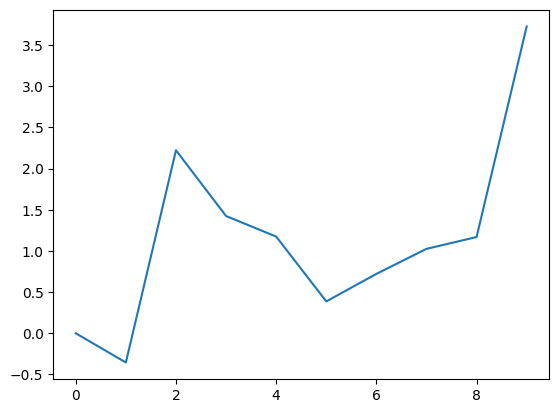

In [18]:
from matplotlib import pyplot as plt

plt.plot(trajectory);